FRACCTURE PARAMETER EXTRACTION CODE FOR PROVIDED DATA FILES


FINAL RESULTS (PLANE STRAIN)
----------------------------
KI  = 1.648 MPa√m
KII = 0.098 MPa√m
T   = 0.110 MPa


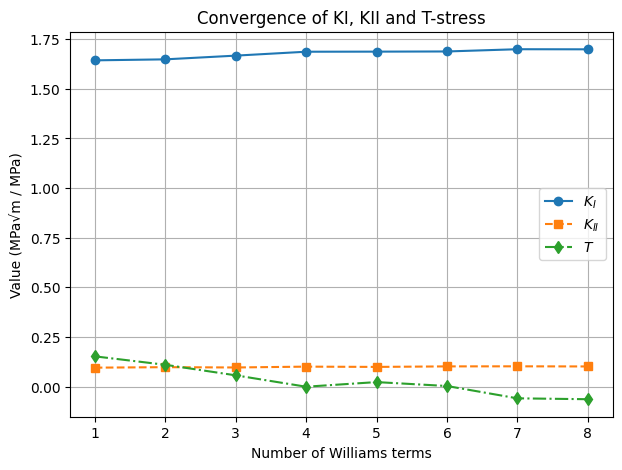

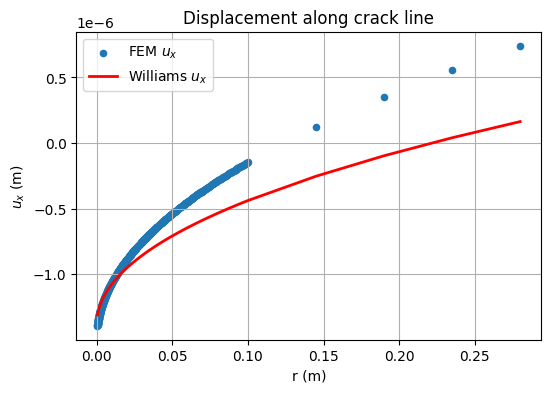

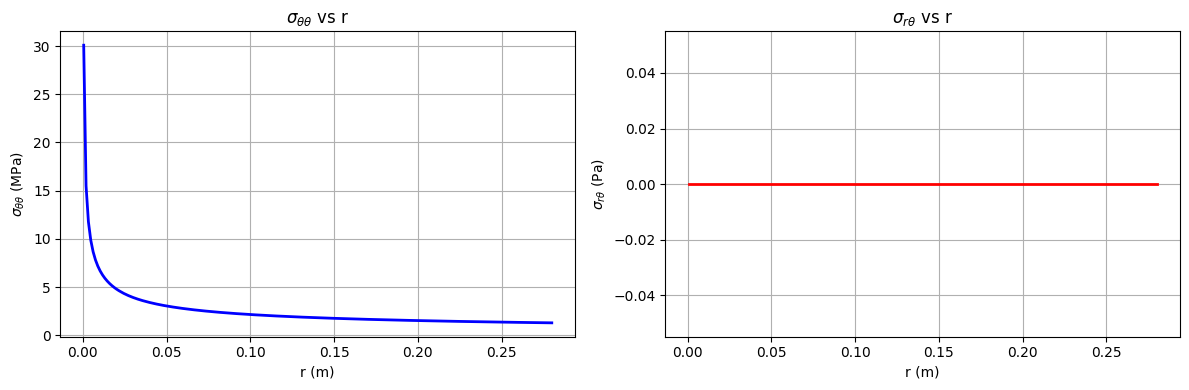

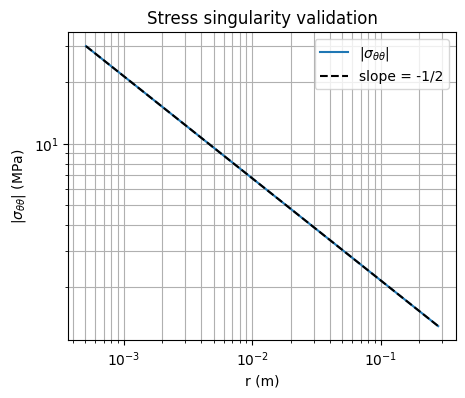

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import lstsq

# ====================================================
# INPUT
# ====================================================
filename = "Data1.xlsx"

# ====================================================
# MATERIAL (PLANE STRAIN)
# ====================================================
E = 200e9
nu = 0.33
mu = E / (2*(1+nu))
kappa = 3 - 4*nu

mm_to_m = 1e-3

# ====================================================
# READ DATA
# ====================================================
df = pd.read_excel(filename)

x = df["X"].values * mm_to_m
y = df["Y"].values * mm_to_m
u = df["U1"].values * mm_to_m
v = df["U2"].values * mm_to_m

r = np.sqrt(x**2 + y**2)
theta = np.arctan2(y, x)

mask = r > 0
r, theta, u, v, x, y = r[mask], theta[mask], u[mask], v[mask], x[mask], y[mask]

# ====================================================
# NEAR-TIP FILTER
# ====================================================
r_min = 5*np.min(r)
r_max = 0.03*np.max(r)
mask = (r > r_min) & (r < r_max)

r, theta, u, v, x, y = r[mask], theta[mask], u[mask], v[mask], x[mask], y[mask]

# ====================================================
# ODM MATRIX (N = 2 → KI, KII, T)
# ====================================================
N_terms = 2
num_nodes = len(r)

A = np.zeros((2*num_nodes, 2*N_terms + 3))
B = np.zeros(2*num_nodes)

for n in range(1, N_terms+1):
    r_term = r**(n/2)

    f1I = (1/(2*mu))*r_term*((kappa + n/2 + (-1)**n)*np.cos(n*theta/2)
                              - (n/2)*np.cos((n/2 - 2)*theta))
    f2I = (1/(2*mu))*r_term*((kappa - n/2 - (-1)**n)*np.sin(n*theta/2)
                              + (n/2)*np.sin((n/2 - 2)*theta))

    f1II = (1/(2*mu))*r_term*((kappa + n/2 - (-1)**n)*np.sin(n*theta/2)
                               - (n/2)*np.sin((n/2 - 2)*theta))
    f2II = -(1/(2*mu))*r_term*((kappa - n/2 + (-1)**n)*np.cos(n*theta/2)
                                + (n/2)*np.cos((n/2 - 2)*theta))

    A[0::2, n-1] = f1I
    A[1::2, n-1] = f2I
    A[0::2, N_terms+n-1] = f1II
    A[1::2, N_terms+n-1] = f2II

# Rigid body modes
A[0::2, -3] = 1
A[1::2, -2] = 1
A[0::2, -1] = -y
A[1::2, -1] = x

B[0::2] = u
B[1::2] = v

# ====================================================
# SOLVE ODM
# ====================================================
sol, _, _, _ = lstsq(A, B)

KI  = sol[0] * np.sqrt(2*np.pi)
KII = sol[N_terms] * np.sqrt(2*np.pi)
T   = 4 * sol[1]

u0 = sol[-3]

print("\nFINAL RESULTS (PLANE STRAIN)")
print("----------------------------")
print(f"KI  = {KI/1e6:.3f} MPa√m")
print(f"KII = {KII/1e6:.3f} MPa√m")
print(f"T   = {T/1e6:.3f} MPa")
# ====================================================
# CONVERGENCE STUDY OF KI, KII, T
# ====================================================
N_max = 8          # you can increase to 10 if data quality is good
N_list = np.arange(1, N_max+1)

KI_list = []
KII_list = []
T_list = []

for N_terms in N_list:

    num_nodes = len(r)
    A = np.zeros((2*num_nodes, 2*N_terms + 3))
    B = np.zeros(2*num_nodes)

    for n in range(1, N_terms+1):
        r_term = r**(n/2)

        f1I = (1/(2*mu))*r_term*((kappa + n/2 + (-1)**n)*np.cos(n*theta/2)
                                  - (n/2)*np.cos((n/2 - 2)*theta))
        f2I = (1/(2*mu))*r_term*((kappa - n/2 - (-1)**n)*np.sin(n*theta/2)
                                  + (n/2)*np.sin((n/2 - 2)*theta))

        f1II = (1/(2*mu))*r_term*((kappa + n/2 - (-1)**n)*np.sin(n*theta/2)
                                   - (n/2)*np.sin((n/2 - 2)*theta))
        f2II = -(1/(2*mu))*r_term*((kappa - n/2 + (-1)**n)*np.cos(n*theta/2)
                                    + (n/2)*np.cos((n/2 - 2)*theta))

        A[0::2, n-1] = f1I
        A[1::2, n-1] = f2I
        A[0::2, N_terms+n-1] = f1II
        A[1::2, N_terms+n-1] = f2II

    # ---- Rigid body terms ----
    A[0::2, -3] = 1
    A[1::2, -2] = 1
    A[0::2, -1] = -y
    A[1::2, -1] = x

    B[0::2] = u
    B[1::2] = v

    # ---- Solve ----
    sol, _, _, _ = lstsq(A, B)

    KI  = sol[0] * np.sqrt(2*np.pi)
    KII = sol[N_terms] * np.sqrt(2*np.pi)
    T   = 4 * sol[1]

    KI_list.append(KI / 1e6)     # MPa√m
    KII_list.append(KII / 1e6)   # MPa√m
    T_list.append(T / 1e6)       # MPa


# ====================================================
# CONVERGENCE PLOT
# ====================================================
plt.figure(figsize=(7,5))
plt.plot(N_list, KI_list, 'o-', label=r'$K_I$')
plt.plot(N_list, KII_list, 's--', label=r'$K_{II}$')
plt.plot(N_list, T_list, 'd-.', label=r'$T$')
plt.xlabel("Number of Williams terms")
plt.ylabel("Value (MPa√m / MPa)")
plt.title("Convergence of KI, KII and T-stress")
plt.grid(True)
plt.legend()
plt.show()


# ====================================================
# DISPLACEMENT COMPARISON (θ ≈ 0)
# ====================================================
theta_tol = 0.03
mask_line = np.abs(theta) < theta_tol

r_l = r[mask_line]
u_fem = u[mask_line]

idx = np.argsort(r_l)
r_l = r_l[idx]
u_fem = u_fem[idx]

u_w = (KI/(2*mu))*np.sqrt(r_l/(2*np.pi))*(kappa - 1) \
      + (T/E)*(1 - nu**2)*r_l + u0

plt.figure(figsize=(6,4))
plt.scatter(r_l, u_fem, s=20, label="FEM $u_x$")
plt.plot(r_l, u_w, 'r-', lw=2, label="Williams $u_x$")
plt.xlabel("r (m)")
plt.ylabel("$u_x$ (m)")
plt.title("Displacement along crack line")
plt.legend()
plt.grid(True)
plt.show()

# ====================================================
# STRESS SINGULARITY VALIDATION (θ = 0)
# ====================================================
r_stress = np.linspace(np.min(r_l), np.max(r_l), 200)

sigma_tt = KI / np.sqrt(2*np.pi*r_stress)   # singular
sigma_rt = np.zeros_like(r_stress)          # zero on crack line

# --- Linear scale ---
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(r_stress, sigma_tt/1e6, 'b', lw=2)
plt.xlabel("r (m)")
plt.ylabel(r"$\sigma_{\theta\theta}$ (MPa)")
plt.title(r"$\sigma_{\theta\theta}$ vs r")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(r_stress, sigma_rt, 'r', lw=2)
plt.xlabel("r (m)")
plt.ylabel(r"$\sigma_{r\theta}$ (Pa)")
plt.title(r"$\sigma_{r\theta}$ vs r")
plt.grid(True)

plt.tight_layout()
plt.show()

# Log-log singularity
plt.figure(figsize=(5,4))
plt.loglog(r_stress, np.abs(sigma_tt)/1e6, label=r'$|\sigma_{\theta\theta}|$')

r_ref = r_stress[len(r_stress)//2]
sig_ref = (np.abs(KI)/np.sqrt(2*np.pi*r_ref))/1e6
plt.loglog(r_stress, sig_ref*(r_stress/r_ref)**(-0.5),
           'k--', label="slope = -1/2")

plt.xlabel("r (m)")
plt.ylabel(r"$|\sigma_{\theta\theta}|$ (MPa)")
plt.title("Stress singularity validation")
plt.legend()
plt.grid(True, which="both")
plt.show()


FINAL RESULTS (PLANE STRAIN)
----------------------------
KI  = 1.757 MPa√m
KII = 2.373 MPa√m
T   = 1.252 MPa


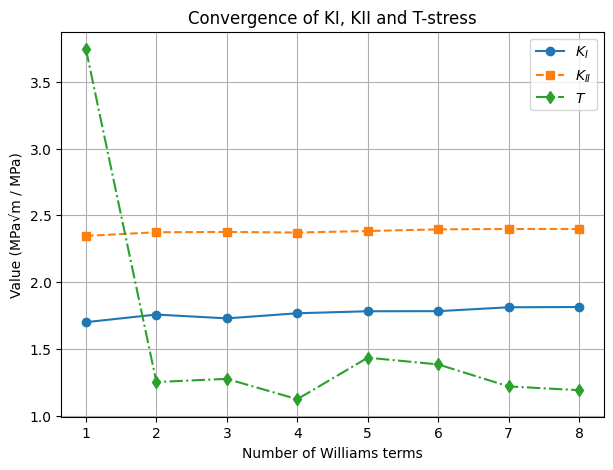

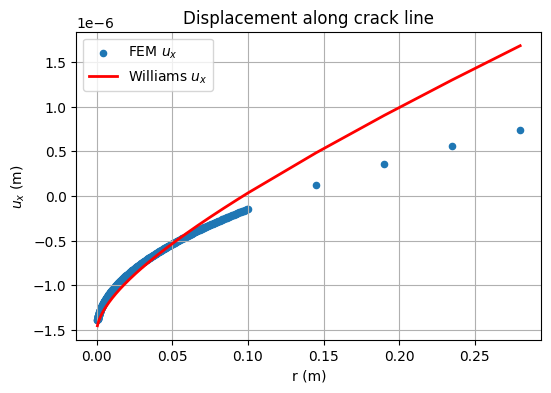

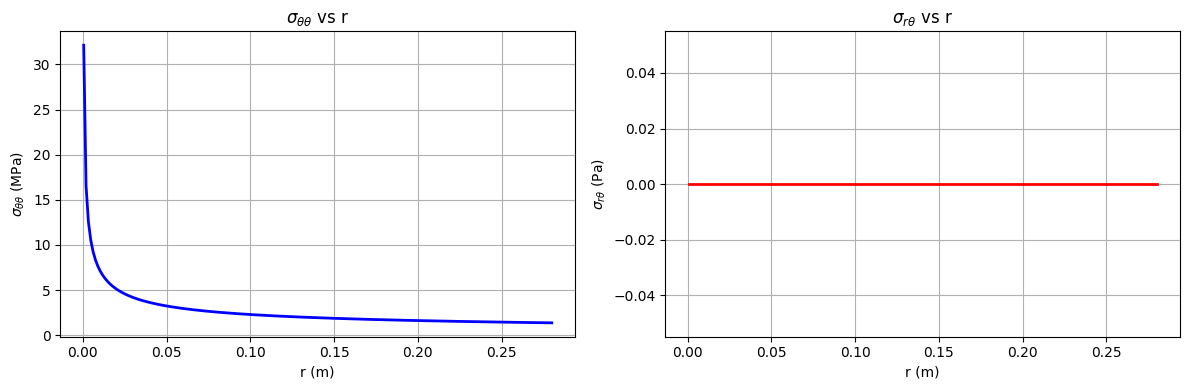

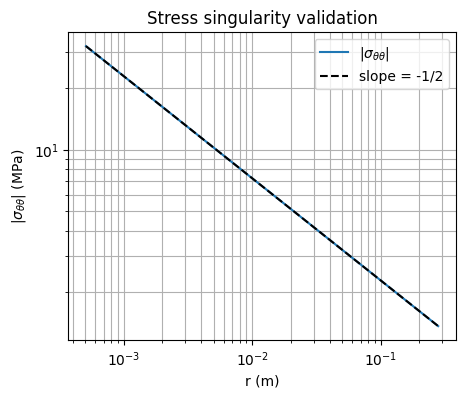

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import lstsq

# ====================================================
# INPUT
# ====================================================
filename = "Data2.xlsx"

# ====================================================
# MATERIAL (PLANE STRAIN)
# ====================================================
E = 200e9
nu = 0.33
mu = E / (2*(1+nu))
kappa = 3 - 4*nu

mm_to_m = 1e-3

# ====================================================
# READ DATA
# ====================================================
df = pd.read_excel(filename)

x = df["X"].values * mm_to_m
y = df["Y"].values * mm_to_m
u = df["U1"].values * mm_to_m
v = df["U2"].values * mm_to_m

r = np.sqrt(x**2 + y**2)
theta = np.arctan2(y, x)

mask = r > 0
r, theta, u, v, x, y = r[mask], theta[mask], u[mask], v[mask], x[mask], y[mask]

# ====================================================
# NEAR-TIP FILTER
# ====================================================
r_min = 5*np.min(r)
r_max = 0.03*np.max(r)
mask = (r > r_min) & (r < r_max)

r, theta, u, v, x, y = r[mask], theta[mask], u[mask], v[mask], x[mask], y[mask]

# ====================================================
# ODM MATRIX (N = 2 → KI, KII, T)
# ====================================================
N_terms = 2
num_nodes = len(r)

A = np.zeros((2*num_nodes, 2*N_terms + 3))
B = np.zeros(2*num_nodes)

for n in range(1, N_terms+1):
    r_term = r**(n/2)

    f1I = (1/(2*mu))*r_term*((kappa + n/2 + (-1)**n)*np.cos(n*theta/2)
                              - (n/2)*np.cos((n/2 - 2)*theta))
    f2I = (1/(2*mu))*r_term*((kappa - n/2 - (-1)**n)*np.sin(n*theta/2)
                              + (n/2)*np.sin((n/2 - 2)*theta))

    f1II = (1/(2*mu))*r_term*((kappa + n/2 - (-1)**n)*np.sin(n*theta/2)
                               - (n/2)*np.sin((n/2 - 2)*theta))
    f2II = -(1/(2*mu))*r_term*((kappa - n/2 + (-1)**n)*np.cos(n*theta/2)
                                + (n/2)*np.cos((n/2 - 2)*theta))

    A[0::2, n-1] = f1I
    A[1::2, n-1] = f2I
    A[0::2, N_terms+n-1] = f1II
    A[1::2, N_terms+n-1] = f2II

# Rigid body modes
A[0::2, -3] = 1
A[1::2, -2] = 1
A[0::2, -1] = -y
A[1::2, -1] = x

B[0::2] = u
B[1::2] = v

# ====================================================
# SOLVE ODM
# ====================================================
sol, _, _, _ = lstsq(A, B)

KI  = sol[0] * np.sqrt(2*np.pi)
KII = sol[N_terms] * np.sqrt(2*np.pi)
T   = 4 * sol[1]

u0 = sol[-3]

print("\nFINAL RESULTS (PLANE STRAIN)")
print("----------------------------")
print(f"KI  = {KI/1e6:.3f} MPa√m")
print(f"KII = {KII/1e6:.3f} MPa√m")
print(f"T   = {T/1e6:.3f} MPa")
# ====================================================
# CONVERGENCE STUDY OF KI, KII, T
# ====================================================
N_max = 8          # you can increase to 10 if data quality is good
N_list = np.arange(1, N_max+1)

KI_list = []
KII_list = []
T_list = []

for N_terms in N_list:

    num_nodes = len(r)
    A = np.zeros((2*num_nodes, 2*N_terms + 3))
    B = np.zeros(2*num_nodes)

    for n in range(1, N_terms+1):
        r_term = r**(n/2)

        f1I = (1/(2*mu))*r_term*((kappa + n/2 + (-1)**n)*np.cos(n*theta/2)
                                  - (n/2)*np.cos((n/2 - 2)*theta))
        f2I = (1/(2*mu))*r_term*((kappa - n/2 - (-1)**n)*np.sin(n*theta/2)
                                  + (n/2)*np.sin((n/2 - 2)*theta))

        f1II = (1/(2*mu))*r_term*((kappa + n/2 - (-1)**n)*np.sin(n*theta/2)
                                   - (n/2)*np.sin((n/2 - 2)*theta))
        f2II = -(1/(2*mu))*r_term*((kappa - n/2 + (-1)**n)*np.cos(n*theta/2)
                                    + (n/2)*np.cos((n/2 - 2)*theta))

        A[0::2, n-1] = f1I
        A[1::2, n-1] = f2I
        A[0::2, N_terms+n-1] = f1II
        A[1::2, N_terms+n-1] = f2II

    # ---- Rigid body terms ----
    A[0::2, -3] = 1
    A[1::2, -2] = 1
    A[0::2, -1] = -y
    A[1::2, -1] = x

    B[0::2] = u
    B[1::2] = v

    # ---- Solve ----
    sol, _, _, _ = lstsq(A, B)

    KI  = sol[0] * np.sqrt(2*np.pi)
    KII = sol[N_terms] * np.sqrt(2*np.pi)
    T   = 4 * sol[1]

    KI_list.append(KI / 1e6)     # MPa√m
    KII_list.append(KII / 1e6)   # MPa√m
    T_list.append(T / 1e6)       # MPa


# ====================================================
# CONVERGENCE PLOT
# ====================================================
plt.figure(figsize=(7,5))
plt.plot(N_list, KI_list, 'o-', label=r'$K_I$')
plt.plot(N_list, KII_list, 's--', label=r'$K_{II}$')
plt.plot(N_list, T_list, 'd-.', label=r'$T$')
plt.xlabel("Number of Williams terms")
plt.ylabel("Value (MPa√m / MPa)")
plt.title("Convergence of KI, KII and T-stress")
plt.grid(True)
plt.legend()
plt.show()


# ====================================================
# DISPLACEMENT COMPARISON (θ ≈ 0)
# ====================================================
theta_tol = 0.03
mask_line = np.abs(theta) < theta_tol

r_l = r[mask_line]
u_fem = u[mask_line]

idx = np.argsort(r_l)
r_l = r_l[idx]
u_fem = u_fem[idx]

u_w = (KI/(2*mu))*np.sqrt(r_l/(2*np.pi))*(kappa - 1) \
      + (T/E)*(1 - nu**2)*r_l + u0

plt.figure(figsize=(6,4))
plt.scatter(r_l, u_fem, s=20, label="FEM $u_x$")
plt.plot(r_l, u_w, 'r-', lw=2, label="Williams $u_x$")
plt.xlabel("r (m)")
plt.ylabel("$u_x$ (m)")
plt.title("Displacement along crack line")
plt.legend()
plt.grid(True)
plt.show()

# ====================================================
# STRESS SINGULARITY VALIDATION (θ = 0)
# ====================================================
r_stress = np.linspace(np.min(r_l), np.max(r_l), 200)

sigma_tt = KI / np.sqrt(2*np.pi*r_stress)   # singular
sigma_rt = np.zeros_like(r_stress)          # zero on crack line

# --- Linear scale ---
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(r_stress, sigma_tt/1e6, 'b', lw=2)
plt.xlabel("r (m)")
plt.ylabel(r"$\sigma_{\theta\theta}$ (MPa)")
plt.title(r"$\sigma_{\theta\theta}$ vs r")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(r_stress, sigma_rt, 'r', lw=2)
plt.xlabel("r (m)")
plt.ylabel(r"$\sigma_{r\theta}$ (Pa)")
plt.title(r"$\sigma_{r\theta}$ vs r")
plt.grid(True)

plt.tight_layout()
plt.show()

# Log-log singularity
plt.figure(figsize=(5,4))
plt.loglog(r_stress, np.abs(sigma_tt)/1e6, label=r'$|\sigma_{\theta\theta}|$')

r_ref = r_stress[len(r_stress)//2]
sig_ref = (np.abs(KI)/np.sqrt(2*np.pi*r_ref))/1e6
plt.loglog(r_stress, sig_ref*(r_stress/r_ref)**(-0.5),
           'k--', label="slope = -1/2")

plt.xlabel("r (m)")
plt.ylabel(r"$|\sigma_{\theta\theta}|$ (MPa)")
plt.title("Stress singularity validation")
plt.legend()
plt.grid(True, which="both")
plt.show()


FINAL RESULTS (PLANE STRAIN)
----------------------------
KI  = -1.924 MPa√m
KII = 1.866 MPa√m
T   = 11.247 MPa


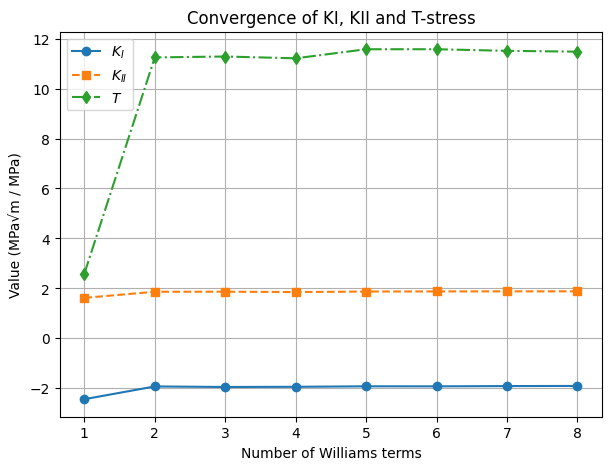

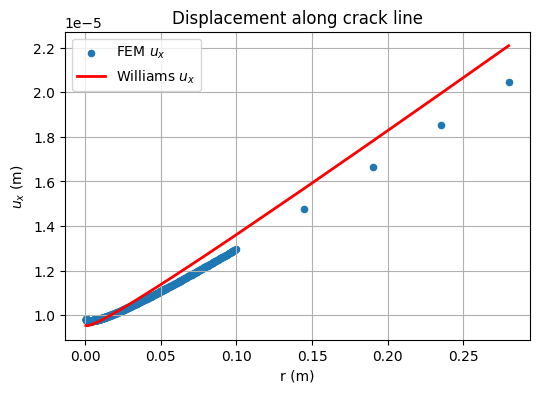

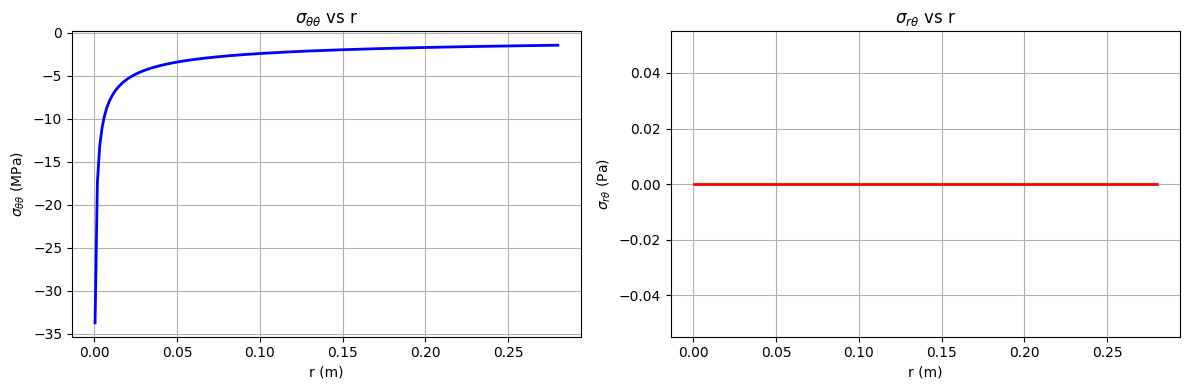

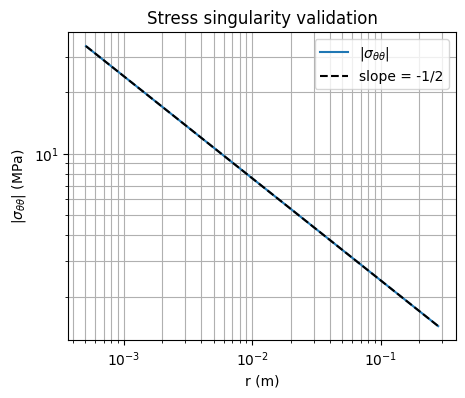

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import lstsq

# ====================================================
# INPUT
# ====================================================
filename = "Data3.xlsx"

# ====================================================
# MATERIAL (PLANE STRAIN)
# ====================================================
E = 200e9
nu = 0.33
mu = E / (2*(1+nu))
kappa = 3 - 4*nu

mm_to_m = 1e-3

# ====================================================
# READ DATA
# ====================================================
df = pd.read_excel(filename)

x = df["X"].values * mm_to_m
y = df["Y"].values * mm_to_m
u = df["U1"].values * mm_to_m
v = df["U2"].values * mm_to_m

r = np.sqrt(x**2 + y**2)
theta = np.arctan2(y, x)

mask = r > 0
r, theta, u, v, x, y = r[mask], theta[mask], u[mask], v[mask], x[mask], y[mask]

# ====================================================
# NEAR-TIP FILTER
# ====================================================
r_min = 5*np.min(r)
r_max = 0.03*np.max(r)
mask = (r > r_min) & (r < r_max)

r, theta, u, v, x, y = r[mask], theta[mask], u[mask], v[mask], x[mask], y[mask]

# ====================================================
# ODM MATRIX (N = 2 → KI, KII, T)
# ====================================================
N_terms = 2
num_nodes = len(r)

A = np.zeros((2*num_nodes, 2*N_terms + 3))
B = np.zeros(2*num_nodes)

for n in range(1, N_terms+1):
    r_term = r**(n/2)

    f1I = (1/(2*mu))*r_term*((kappa + n/2 + (-1)**n)*np.cos(n*theta/2)
                              - (n/2)*np.cos((n/2 - 2)*theta))
    f2I = (1/(2*mu))*r_term*((kappa - n/2 - (-1)**n)*np.sin(n*theta/2)
                              + (n/2)*np.sin((n/2 - 2)*theta))

    f1II = (1/(2*mu))*r_term*((kappa + n/2 - (-1)**n)*np.sin(n*theta/2)
                               - (n/2)*np.sin((n/2 - 2)*theta))
    f2II = -(1/(2*mu))*r_term*((kappa - n/2 + (-1)**n)*np.cos(n*theta/2)
                                + (n/2)*np.cos((n/2 - 2)*theta))

    A[0::2, n-1] = f1I
    A[1::2, n-1] = f2I
    A[0::2, N_terms+n-1] = f1II
    A[1::2, N_terms+n-1] = f2II

# Rigid body modes
A[0::2, -3] = 1
A[1::2, -2] = 1
A[0::2, -1] = -y
A[1::2, -1] = x

B[0::2] = u
B[1::2] = v

# ====================================================
# SOLVE ODM
# ====================================================
sol, _, _, _ = lstsq(A, B)

KI  = sol[0] * np.sqrt(2*np.pi)
KII = sol[N_terms] * np.sqrt(2*np.pi)
T   = 4 * sol[1]

u0 = sol[-3]

print("\nFINAL RESULTS (PLANE STRAIN)")
print("----------------------------")
print(f"KI  = {KI/1e6:.3f} MPa√m")
print(f"KII = {KII/1e6:.3f} MPa√m")
print(f"T   = {T/1e6:.3f} MPa")
# ====================================================
# CONVERGENCE STUDY OF KI, KII, T
# ====================================================
N_max = 8          # you can increase to 10 if data quality is good
N_list = np.arange(1, N_max+1)

KI_list = []
KII_list = []
T_list = []

for N_terms in N_list:

    num_nodes = len(r)
    A = np.zeros((2*num_nodes, 2*N_terms + 3))
    B = np.zeros(2*num_nodes)

    for n in range(1, N_terms+1):
        r_term = r**(n/2)

        f1I = (1/(2*mu))*r_term*((kappa + n/2 + (-1)**n)*np.cos(n*theta/2)
                                  - (n/2)*np.cos((n/2 - 2)*theta))
        f2I = (1/(2*mu))*r_term*((kappa - n/2 - (-1)**n)*np.sin(n*theta/2)
                                  + (n/2)*np.sin((n/2 - 2)*theta))

        f1II = (1/(2*mu))*r_term*((kappa + n/2 - (-1)**n)*np.sin(n*theta/2)
                                   - (n/2)*np.sin((n/2 - 2)*theta))
        f2II = -(1/(2*mu))*r_term*((kappa - n/2 + (-1)**n)*np.cos(n*theta/2)
                                    + (n/2)*np.cos((n/2 - 2)*theta))

        A[0::2, n-1] = f1I
        A[1::2, n-1] = f2I
        A[0::2, N_terms+n-1] = f1II
        A[1::2, N_terms+n-1] = f2II

    # ---- Rigid body terms ----
    A[0::2, -3] = 1
    A[1::2, -2] = 1
    A[0::2, -1] = -y
    A[1::2, -1] = x

    B[0::2] = u
    B[1::2] = v

    # ---- Solve ----
    sol, _, _, _ = lstsq(A, B)

    KI  = sol[0] * np.sqrt(2*np.pi)
    KII = sol[N_terms] * np.sqrt(2*np.pi)
    T   = 4 * sol[1]

    KI_list.append(KI / 1e6)     # MPa√m
    KII_list.append(KII / 1e6)   # MPa√m
    T_list.append(T / 1e6)       # MPa


# ====================================================
# CONVERGENCE PLOT
# ====================================================
plt.figure(figsize=(7,5))
plt.plot(N_list, KI_list, 'o-', label=r'$K_I$')
plt.plot(N_list, KII_list, 's--', label=r'$K_{II}$')
plt.plot(N_list, T_list, 'd-.', label=r'$T$')
plt.xlabel("Number of Williams terms")
plt.ylabel("Value (MPa√m / MPa)")
plt.title("Convergence of KI, KII and T-stress")
plt.grid(True)
plt.legend()
plt.show()


# ====================================================
# DISPLACEMENT COMPARISON (θ ≈ 0)
# ====================================================
theta_tol = 0.03
mask_line = np.abs(theta) < theta_tol

r_l = r[mask_line]
u_fem = u[mask_line]

idx = np.argsort(r_l)
r_l = r_l[idx]
u_fem = u_fem[idx]

u_w = (KI/(2*mu))*np.sqrt(r_l/(2*np.pi))*(kappa - 1) \
      + (T/E)*(1 - nu**2)*r_l + u0

plt.figure(figsize=(6,4))
plt.scatter(r_l, u_fem, s=20, label="FEM $u_x$")
plt.plot(r_l, u_w, 'r-', lw=2, label="Williams $u_x$")
plt.xlabel("r (m)")
plt.ylabel("$u_x$ (m)")
plt.title("Displacement along crack line")
plt.legend()
plt.grid(True)
plt.show()

# ====================================================
# STRESS SINGULARITY VALIDATION (θ = 0)
# ====================================================
r_stress = np.linspace(np.min(r_l), np.max(r_l), 200)

sigma_tt = KI / np.sqrt(2*np.pi*r_stress)   # singular
sigma_rt = np.zeros_like(r_stress)          # zero on crack line

# --- Linear scale ---
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(r_stress, sigma_tt/1e6, 'b', lw=2)
plt.xlabel("r (m)")
plt.ylabel(r"$\sigma_{\theta\theta}$ (MPa)")
plt.title(r"$\sigma_{\theta\theta}$ vs r")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(r_stress, sigma_rt, 'r', lw=2)
plt.xlabel("r (m)")
plt.ylabel(r"$\sigma_{r\theta}$ (Pa)")
plt.title(r"$\sigma_{r\theta}$ vs r")
plt.grid(True)

plt.tight_layout()
plt.show()

# Log-log singularity
plt.figure(figsize=(5,4))
plt.loglog(r_stress, np.abs(sigma_tt)/1e6, label=r'$|\sigma_{\theta\theta}|$')

r_ref = r_stress[len(r_stress)//2]
sig_ref = (np.abs(KI)/np.sqrt(2*np.pi*r_ref))/1e6
plt.loglog(r_stress, sig_ref*(r_stress/r_ref)**(-0.5),
           'k--', label="slope = -1/2")

plt.xlabel("r (m)")
plt.ylabel(r"$|\sigma_{\theta\theta}|$ (MPa)")
plt.title("Stress singularity validation")
plt.legend()
plt.grid(True, which="both")
plt.show()

EXPERIMENTAL PARAMETER EXTRACTION

Mounted at /content/drive


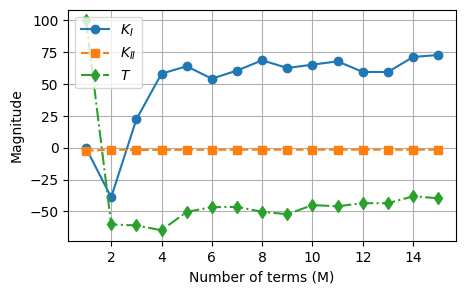

KI  = 1.911 MPa√m
KII = -0.050 MPa√m
T   = -46.471 MPa


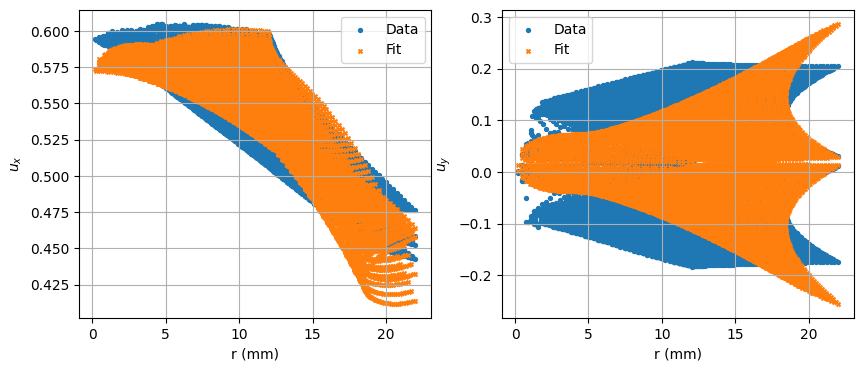

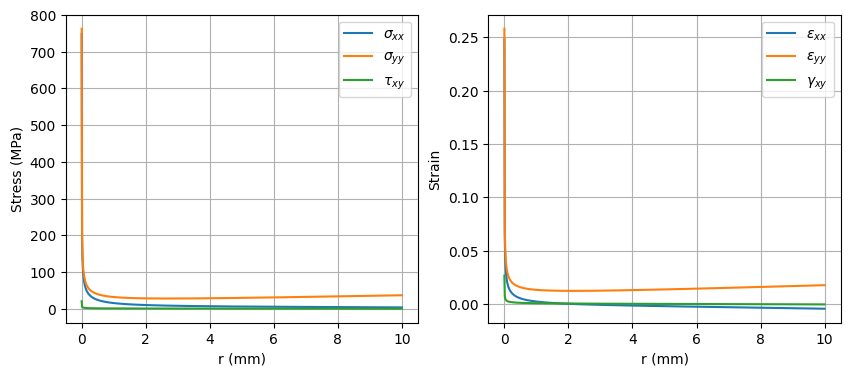

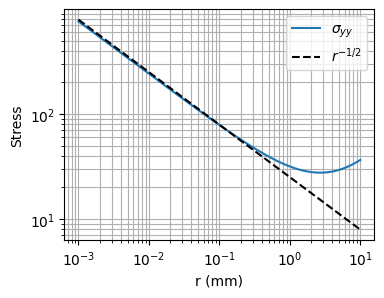

In [2]:
 import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import lstsq

# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

# Material properties

FILE_PATH = "/content/drive/MyDrive/FRACTURE MECHANICS/20feb_3PB_2.csv"
E  = 2e3
nu = 0.33
mu = E/(2*(1+nu))
kappa = 3 - 4*nu

M_MAX = 15
M_USE = 7

# Load displacement data

data = pd.read_csv(FILE_PATH).dropna()

x  = data["X"].values
y  = data["Y"].values
ux = data["U"].values
uy = data["V"].values

r = np.sqrt(x**2 + y**2)
theta = np.arctan2(y, x)

b = np.hstack([ux, uy])

# Williams displacement matrix

def build_williams_matrix(r, theta, M, kappa):
    N = len(r)
    A = np.zeros((2*N, 2*M + 3))

    for n in range(1, M+1):
        rn = r**(n/2)
        t1 = (n/2)*theta
        t2 = (n/2 - 2)*theta

        c1, s1 = np.cos(t1), np.sin(t1)
        c2, s2 = np.cos(t2), np.sin(t2)

        ca = 2*(n-1)
        cb = ca + 1

        A[:N, ca] = rn*((kappa + n/2 + (-1)**n)*c1 - (n/2)*c2)
        A[:N, cb] = -rn*((kappa + n/2 - (-1)**n)*s1 - (n/2)*s2)

        A[N:, ca] = rn*((kappa - n/2 - (-1)**n)*s1 + (n/2)*s2)
        A[N:, cb] = rn*((kappa - n/2 + (-1)**n)*c1 + (n/2)*c2)

    A[:N, -3] = r*np.cos(theta)
    A[N:, -3] = r*np.sin(theta)

    A[:N, -2] = 1.0
    A[N:, -1] = 1.0

    return A

# Convergence study

KI_conv, KII_conv, T_conv = [], [], []

for M in range(1, M_MAX+1):
    A = build_williams_matrix(r, theta, M, kappa)
    coeffs, _, _, _ = lstsq(A, b, rcond=None)

    a1 = coeffs[0]
    b1 = coeffs[1]

    KI  = (2*mu*a1)*np.sqrt(2*np.pi)
    KII = (2*mu*b1)*np.sqrt(2*np.pi)

    if len(coeffs) > 2:
        a2 = coeffs[2]
        T = 4*np.pi*(2*mu*a2)
    else:
        T = np.nan

    KI_conv.append(KI)
    KII_conv.append(KII)
    T_conv.append(T)

plt.figure(figsize=(5,3))
plt.plot(range(1, M_MAX+1), KI_conv,  'o-', label=r"$K_I$")
plt.plot(range(1, M_MAX+1), KII_conv, 's--', label=r"$K_{II}$")
plt.plot(range(1, M_MAX+1), T_conv,   'd-.', label=r"$T$")
plt.xlabel("Number of terms (M)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.legend()
plt.show()

# Final extraction (M = 7)

A = build_williams_matrix(r, theta, M_USE, kappa)
coeffs, _, _, _ = lstsq(A, b, rcond=None)

a1, b1, a2 = coeffs[0], coeffs[1], coeffs[2]

KI  = (2*mu*a1)*np.sqrt(2*np.pi)
KII = (2*mu*b1)*np.sqrt(2*np.pi)
T   = 4*np.pi*(2*mu*a2)

alpha, U0, V0 = coeffs[-3], coeffs[-2], coeffs[-1]


# Convert from MPa√mm → MPa√m
conv = 1.0 / np.sqrt(1000.0)

print(f"KI  = {(KI * conv):.3f} MPa√m")
print(f"KII = {(KII * conv):.3f} MPa√m")
print(f"T   = {T:.3f} MPa")   # T-stress needs no conversion

# Displacement comparison

u_fit = A @ coeffs
ux_fit = u_fit[:len(r)]
uy_fit = u_fit[len(r):]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(r, ux, s=8, label="Data")
plt.scatter(r, ux_fit, s=8, marker='x', label="Fit")
plt.xlabel("r (mm)")
plt.ylabel("$u_x$")
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(r, uy, s=8, label="Data")
plt.scatter(r, uy_fit, s=8, marker='x', label="Fit")
plt.xlabel("r (mm)")
plt.ylabel("$u_y$")
plt.legend(); plt.grid(True)

plt.show()

# Stress and strain fields

def stress_strain_williams(r, theta, coeffs, M, mu, nu):
    sxx = np.zeros_like(r)
    syy = np.zeros_like(r)
    txy = np.zeros_like(r)

    for n in range(1, M+1):
        An = coeffs[2*(n-1)] * 2*mu
        Bn = coeffs[2*(n-1)+1] * 2*mu

        fac = (n/2)*r**(n/2 - 1)
        t1 = (n/2)*theta
        t2 = (n/2 - 2)*theta

        sxx += fac*(An*((2+n/2+(-1)**n)*np.cos(t1)-(n/2-1)*np.cos(t2))
                   -Bn*((2+n/2-(-1)**n)*np.sin(t1)-(n/2-1)*np.sin(t2)))

        syy += fac*(An*((2-n/2-(-1)**n)*np.cos(t1)+(n/2-1)*np.cos(t2))
                   -Bn*((2-n/2+(-1)**n)*np.sin(t1)+(n/2-1)*np.sin(t2)))

        txy += fac*(An*(-(n/2+(-1)**n)*np.sin(t1)+(n/2-1)*np.sin(t2))
                   -Bn*((n/2-(-1)**n)*np.cos(t1)-(n/2-1)*np.cos(t2)))

    exx = (sxx - nu*syy)/E
    eyy = (syy - nu*sxx)/E
    gxy = txy/mu

    return sxx, syy, txy, exx, eyy, gxy

# Crack-tip fields

r_plot = np.linspace(0.001, 10.0, 800)
theta_plot = np.zeros_like(r_plot)

sxx, syy, txy, exx, eyy, gxy = stress_strain_williams(
    r_plot, theta_plot, coeffs, M_USE, mu, nu
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(r_plot, sxx, label=r'$\sigma_{xx}$')
plt.plot(r_plot, syy, label=r'$\sigma_{yy}$')
plt.plot(r_plot, txy, label=r'$\tau_{xy}$')
plt.xlabel("r (mm)")
plt.ylabel("Stress (MPa)")
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(r_plot, exx, label=r'$\varepsilon_{xx}$')
plt.plot(r_plot, eyy, label=r'$\varepsilon_{yy}$')
plt.plot(r_plot, gxy, label=r'$\gamma_{xy}$')
plt.xlabel("r (mm)")
plt.ylabel("Strain")
plt.legend(); plt.grid(True)

plt.show()

# Singularity check

plt.figure(figsize=(4,3))
plt.loglog(r_plot, abs(syy), label=r'$\sigma_{yy}$')
plt.loglog(r_plot, syy[10]*(r_plot/r_plot[10])**(-0.5), 'k--', label=r'$r^{-1/2}$')
plt.xlabel("r (mm)")
plt.ylabel("Stress")
plt.legend()
plt.grid(True, which="both")
plt.show()